# 07 - Statistical Deep Dive

Comprehensive statistical validation of the Blue Zones longevity analysis.
Includes confidence intervals, significance tests, GDP-controlled correlations,
gender analysis, sensitivity tests, regional comparisons, and time-series analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if not os.path.exists(os.path.join(PROJECT_DIR, 'outputs')):
    PROJECT_DIR = os.path.abspath('..')

OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs', 'analysis')
FIGURE_DIR = os.path.join(PROJECT_DIR, 'outputs', 'figures')
print(f'Project: {PROJECT_DIR}')
print(f'Output files: {len(os.listdir(OUTPUT_DIR))}')


Project: /home/yeblad/Blue-Zones-Longevity-Analysis
Output files: 27


## 1. Blue Zone Gap: Confidence Intervals and Significance

Bootstrap 95% confidence intervals on the BZ-global life expectancy gap.
P-value tests whether a random set of 5 countries would show this gap by chance.

In [2]:
gap_ci = pd.read_csv(os.path.join(OUTPUT_DIR, 'gap_confidence_intervals.csv'))
print(f"Years analyzed: {len(gap_ci)}")
print(f"Significant at p<0.05: {gap_ci['significant_at_05'].sum()}/{len(gap_ci)} years")
print(f"Gap range: {gap_ci['gap'].min():.2f} to {gap_ci['gap'].max():.2f} years")
print(f"\nMost recent (2023):")
last = gap_ci.iloc[-1]
print(f"  Gap: {last['gap']:.2f} years, 95% CI: [{last['ci_lower']:.2f}, {last['ci_upper']:.2f}], p={last['p_value']:.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gap_ci['year'], gap_ci['gap'], 'b-', linewidth=2, label='BZ-Global Gap')
ax.fill_between(gap_ci['year'], gap_ci['ci_lower'], gap_ci['ci_upper'],
                alpha=0.2, color='blue', label='95% CI')
ax.axvspan(2020, 2023, alpha=0.1, color='red', label='COVID period')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Life Expectancy Gap (years)', fontsize=12)
ax.set_title('Blue Zone Advantage with 95% Confidence Intervals', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'nb07_gap_ci_ribbon.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb07_gap_ci_ribbon.png")


Years analyzed: 64
Significant at p<0.05: 64/64 years
Gap range: 5.95 to 10.63 years

Most recent (2023):
  Gap: 6.19 years, 95% CI: [3.92, 8.39], p=0.0060
Saved: nb07_gap_ci_ribbon.png


## 2. Beta Convergence: P-values with Bonferroni Correction

Pearson correlation between initial LE and subsequent gains by decade.
Bonferroni correction applied for 6 simultaneous tests.

In [3]:
beta = pd.read_csv(os.path.join(OUTPUT_DIR, 'beta_convergence_pvalues.csv'))
print("Beta Convergence Results:")
print(beta[['decade', 'n_countries', 'beta_r', 'p_value', 'p_value_bonferroni', 'significant_at_05']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2166ac' if s else '#d6604d' for s in beta['significant_at_05']]
bars = ax.bar(beta['decade'], beta['beta_r'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Pearson r (Initial LE vs Gains)', fontsize=12)
ax.set_title('Beta Convergence by Decade (blue = significant after Bonferroni)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for bar, p in zip(bars, beta['p_value_bonferroni']):
    if p < 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
                f'p={p:.4f}', ha='center', va='top', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'nb07_beta_pvalues.png'), dpi=150, bbox_inches='tight')
plt.show()


Beta Convergence Results:
   decade  n_countries    beta_r      p_value  p_value_bonferroni  significant_at_05
1960-1970           92 -0.574805 2.073265e-09        1.243959e-08               True
1970-1980           93 -0.449965 6.036491e-06        3.621895e-05               True
1980-1990           93 -0.213024 4.035122e-02        2.421073e-01              False
1990-2000           93 -0.087705 4.031740e-01        1.000000e+00              False
2000-2010           93 -0.651764 1.489019e-12        8.934116e-12               True
2010-2019           93 -0.640625 4.661247e-12        2.796748e-11               True


## 3. Sigma Convergence: Trend Test

OLS regression of cross-country LE standard deviation on year.
Bartlett's test comparing first-decade vs last-decade variance.

In [4]:
sigma = pd.read_csv(os.path.join(OUTPUT_DIR, 'sigma_convergence_test.csv'))
print("Sigma Convergence Results:")
for _, row in sigma.iterrows():
    print(f"  {row['period']}:")
    print(f"    Slope: {row['slope']:.4f} SD units/year")
    print(f"    P-value: {row['slope_p_value']:.6f}")
    print(f"    R-squared: {row['r_squared']:.3f}")
    print(f"    Bartlett's test p-value: {row['bartlett_p_value']:.4f}")
    print(f"    Conclusion: {'SD is declining significantly' if row['sigma_declining'] else 'No significant decline'}")


Sigma Convergence Results:
  pre_covid:
    Slope: -0.0531 SD units/year
    P-value: 0.000000
    R-squared: 0.846
    Bartlett's test p-value: 0.0011
    Conclusion: SD is declining significantly
  full_period:
    Slope: -0.0561 SD units/year
    P-value: 0.000000
    R-squared: 0.866
    Bartlett's test p-value: 0.0001
    Conclusion: SD is declining significantly


## 4. Partial Correlations: Controlling for GDP

Raw correlation vs GDP-controlled partial correlation for each indicator.
Identifies which relationships with LE are driven by wealth vs independent factors.

In [5]:
partial = pd.read_csv(os.path.join(OUTPUT_DIR, 'partial_correlations.csv'))
print("Partial Correlations (controlling for GDP per capita):\n")
display_cols = ['indicator', 'n_countries', 'raw_correlation', 'partial_correlation_gdp_controlled', 'correlation_change', 'gdp_explains_relationship']
print(partial[display_cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = range(len(partial))
ax.barh([y - 0.2 for y in y_pos], partial['raw_correlation'], height=0.35,
        color='#67a9cf', label='Raw Correlation', edgecolor='black', linewidth=0.5)
ax.barh([y + 0.2 for y in y_pos], partial['partial_correlation_gdp_controlled'], height=0.35,
        color='#ef8a62', label='GDP-Controlled', edgecolor='black', linewidth=0.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(partial['indicator'], fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with Life Expectancy', fontsize=12)
ax.set_title('Raw vs GDP-Controlled Correlations with Life Expectancy', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'nb07_partial_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()


Partial Correlations (controlling for GDP per capita):

             indicator  n_countries  raw_correlation  partial_correlation_gdp_controlled  correlation_change  gdp_explains_relationship
        fertility_rate           93        -0.820296                           -0.762062            0.058234                      False
clean_water_access_pct           78         0.854429                            0.751754           -0.102674                      False
   physicians_per_1000           27         0.837010                            0.681724           -0.155286                      False
 population_65plus_pct           93         0.774158                            0.647250           -0.126909                      False
  urban_population_pct           93         0.681012                            0.514140           -0.166872                      False
            gini_index           40        -0.340562                           -0.146663            0.193899                    

## 5. Multiple Regression Results

OLS: life_expectancy ~ GDP + physicians + urbanization + health expenditure.
VIF values check for multicollinearity.

In [6]:
reg = pd.read_csv(os.path.join(OUTPUT_DIR, 'regression_results.csv'))
meta = pd.read_csv(os.path.join(OUTPUT_DIR, 'regression_meta.csv'))
vif = pd.read_csv(os.path.join(OUTPUT_DIR, 'regression_vif.csv'))

print("Regression Model:")
print(f"  R-squared: {meta['r_squared'].iloc[0]:.3f}")
print(f"  Adjusted R-squared: {meta['adj_r_squared'].iloc[0]:.3f}")
print(f"  F-statistic p-value: {meta['f_p_value'].iloc[0]:.6f}")
print(f"  N observations: {int(meta['n_observations'].iloc[0])}\n")

print("Coefficients:")
print(reg[['predictor', 'coefficient', 'std_error', 'p_value', 'significant_at_05']].to_string(index=False))
print("\nVIF (Variance Inflation Factors):")
print(vif.to_string(index=False))
print("\nNote: VIF > 10 indicates problematic multicollinearity")


Regression Model:
  R-squared: 0.706
  Adjusted R-squared: 0.693
  F-statistic p-value: 0.000000
  N observations: 92

Coefficients:
            predictor  coefficient  std_error      p_value  significant_at_05
          (intercept)    63.479160   1.424617 1.100911e-61               True
       gdp_per_capita     0.000076   0.000037 4.085637e-02               True
  physicians_per_1000     1.786612   0.336933 8.560224e-07               True
 urban_population_pct     0.082054   0.026169 2.340143e-03               True
health_expenditure_pc    -0.000080   0.000364 8.271609e-01              False

VIF (Variance Inflation Factors):
            predictor      vif
       gdp_per_capita 6.721411
  physicians_per_1000 2.063135
 urban_population_pct 1.862722
health_expenditure_pc 6.560537

Note: VIF > 10 indicates problematic multicollinearity


## 6. Sensitivity Analysis: Drop-One-Country

Removing each BZ country one at a time to test robustness of findings.
Key question: Does any single country drive the results?

In [7]:
sens = pd.read_csv(os.path.join(OUTPUT_DIR, 'sensitivity_drop_one.csv'))
print("Sensitivity Analysis (baseline gap shown in title):\n")
print(sens[['dropped_country', 'dropped_le_2019', 'gap_2019', 'gap_change', 'gap_change_pct']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d6604d' if c < 0 else '#2166ac' for c in sens['gap_change']]
bars = ax.bar(sens['dropped_country'], sens['gap_change'], color=colors,
              edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylabel('Change in BZ Gap (years)', fontsize=12)
ax.set_title('Effect of Removing Each Blue Zone Country on BZ-Global Gap', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, sens['gap_change']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'nb07_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


Sensitivity Analysis (baseline gap shown in title):

dropped_country  dropped_le_2019  gap_2019  gap_change  gap_change_pct
     Costa Rica        80.296000  7.099549    0.354837        5.260959
         Greece        81.639024  6.763793    0.019080        0.282895
          Italy        83.497561  6.299159   -0.445554       -6.605970
          Japan        84.356341  6.084464   -0.660249       -9.789132
  United States        78.787805  7.476598    0.731885       10.851246


## 7. Gender Analysis: Male vs Female Life Expectancy

Comparing the BZ advantage separately for males and females.
Tracking the gender gap (F-M) in BZ countries vs global average.

Gender Analysis (2010-2023 average):
  Male BZ advantage: 7.13 years
  Female BZ advantage: 7.13 years
  BZ gender gap (F-M): 5.34 years
  Global gender gap (F-M): 5.34 years


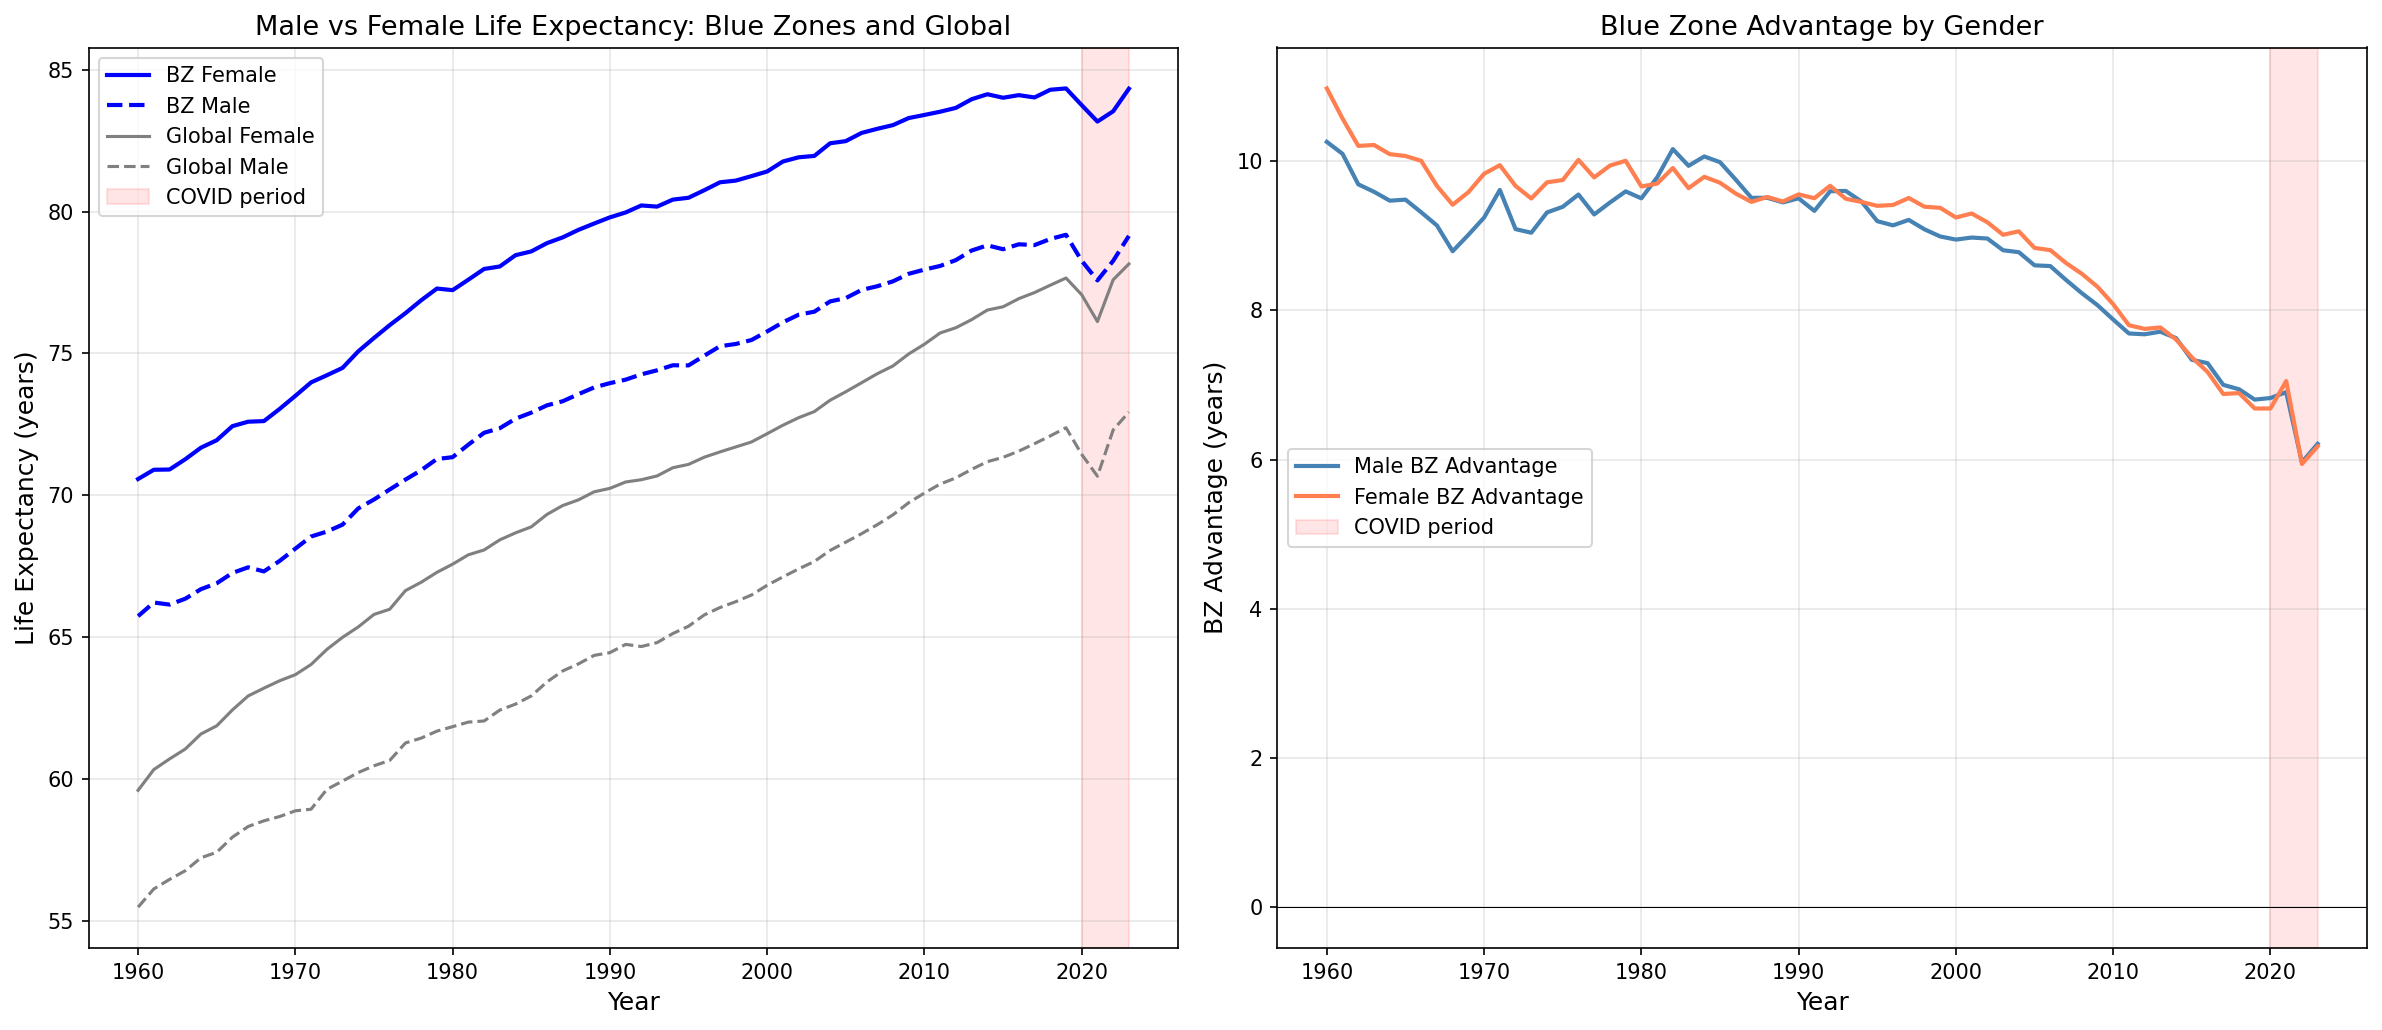

Displayed: nb07_gender_le_trends.png


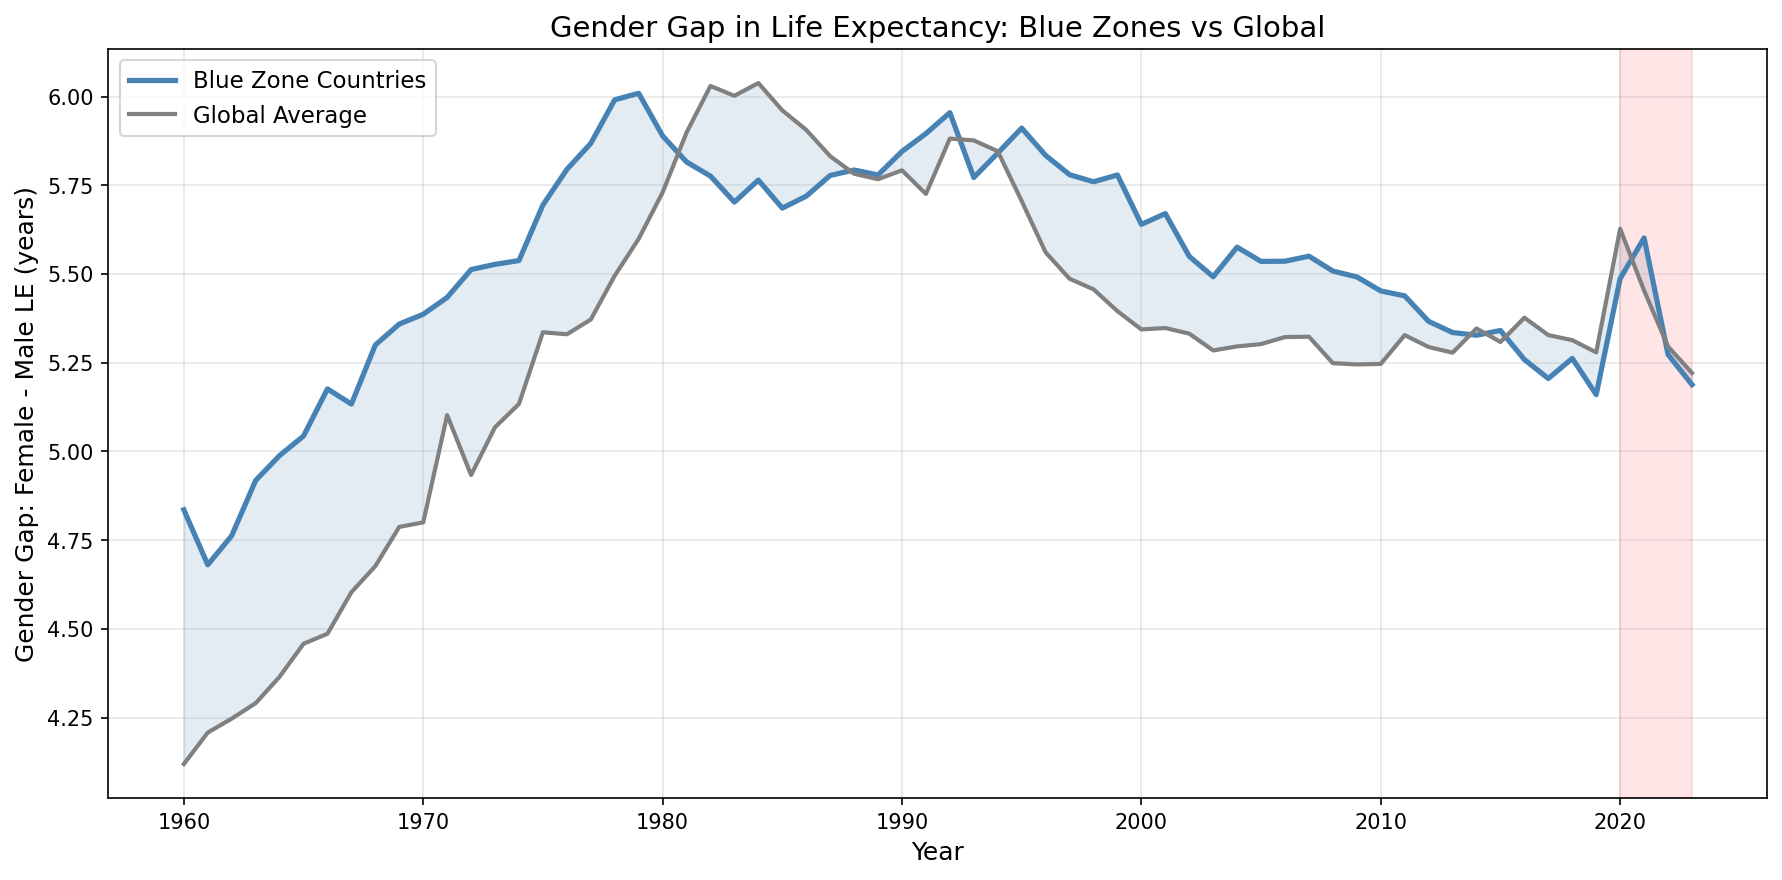

Displayed: nb07_gender_gap_comparison.png


In [8]:
gender = pd.read_csv(os.path.join(OUTPUT_DIR, 'gender_gap_analysis.csv'))
recent = gender[gender['year'] >= 2010]

print("Gender Analysis (2010-2023 average):")
print(f"  Male BZ advantage: {recent['male_gap'].mean():.2f} years")
print(f"  Female BZ advantage: {recent['female_gap'].mean():.2f} years")
print(f"  BZ gender gap (F-M): {recent['bz_gender_gap'].mean():.2f} years")
print(f"  Global gender gap (F-M): {recent['global_gender_gap'].mean():.2f} years")

# Show the saved figures
from IPython.display import Image, display
for fig_name in ['nb07_gender_le_trends.png', 'nb07_gender_gap_comparison.png']:
    fig_path = os.path.join(FIGURE_DIR, fig_name)
    if os.path.exists(fig_path):
        display(Image(filename=fig_path))
        print(f"Displayed: {fig_name}")


## 8. Population-Weighted vs Unweighted Averages

Does weighting by population change the BZ gap meaningfully?
Large countries (China, India) have lower LE, which could shift the weighted average.

In [9]:
pw = pd.read_csv(os.path.join(OUTPUT_DIR, 'population_weighted_gap.csv'))
recent = pw[pw['year'] >= 2000]

print("Population Weighting Effect (2000-2023):")
print(f"  Average unweighted gap: {recent['gap_unweighted'].mean():.2f} years")
print(f"  Average weighted gap: {recent['gap_weighted'].mean():.2f} years")
print(f"  Weighting effect: {recent['gap_difference'].mean():.2f} years")
print(f"\n  Weighting increases the gap because large developing countries")
print(f"  (China, India, etc.) pull down the population-weighted global average.")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pw['year'], pw['gap_unweighted'], 'b-', linewidth=2, label='Unweighted Gap')
ax.plot(pw['year'], pw['gap_weighted'], 'r--', linewidth=2, label='Population-Weighted Gap')
ax.fill_between(pw['year'], pw['gap_unweighted'], pw['gap_weighted'],
                alpha=0.1, color='purple')
ax.axvspan(2020, 2023, alpha=0.1, color='red', label='COVID period')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('BZ-Global Gap (years)', fontsize=12)
ax.set_title('Unweighted vs Population-Weighted BZ Advantage', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'nb07_weighted_gap.png'), dpi=150, bbox_inches='tight')
plt.show()


Population Weighting Effect (2000-2023):
  Average unweighted gap: 7.82 years
  Average weighted gap: 8.93 years
  Weighting effect: -1.12 years

  Weighting increases the gap because large developing countries
  (China, India, etc.) pull down the population-weighted global average.


## 9. Regional Peer Comparison

Each BZ country compared to its geographic region's average.
Tests whether BZ countries are true regional outliers.

Regional Outlier Tests (2000-2019):

bz_country                         region  mean_advantage_2000_2019      p_value  is_regional_outlier
       JPN            East Asia & Pacific                  9.672245 5.145292e-49                 True
       ITA                Southern Europe                  4.317200 4.728970e-43                 True
       GRC                Southern Europe                  2.516688 1.144852e-37                 True
       CRI        Central & South America                  5.545782 2.722885e-40                 True
       USA North America & Western Europe                 -2.451193 1.291013e-19                False

Key finding: USA is BELOW its regional peer average (North America & Western Europe)
All other BZ countries are significantly above their regions.


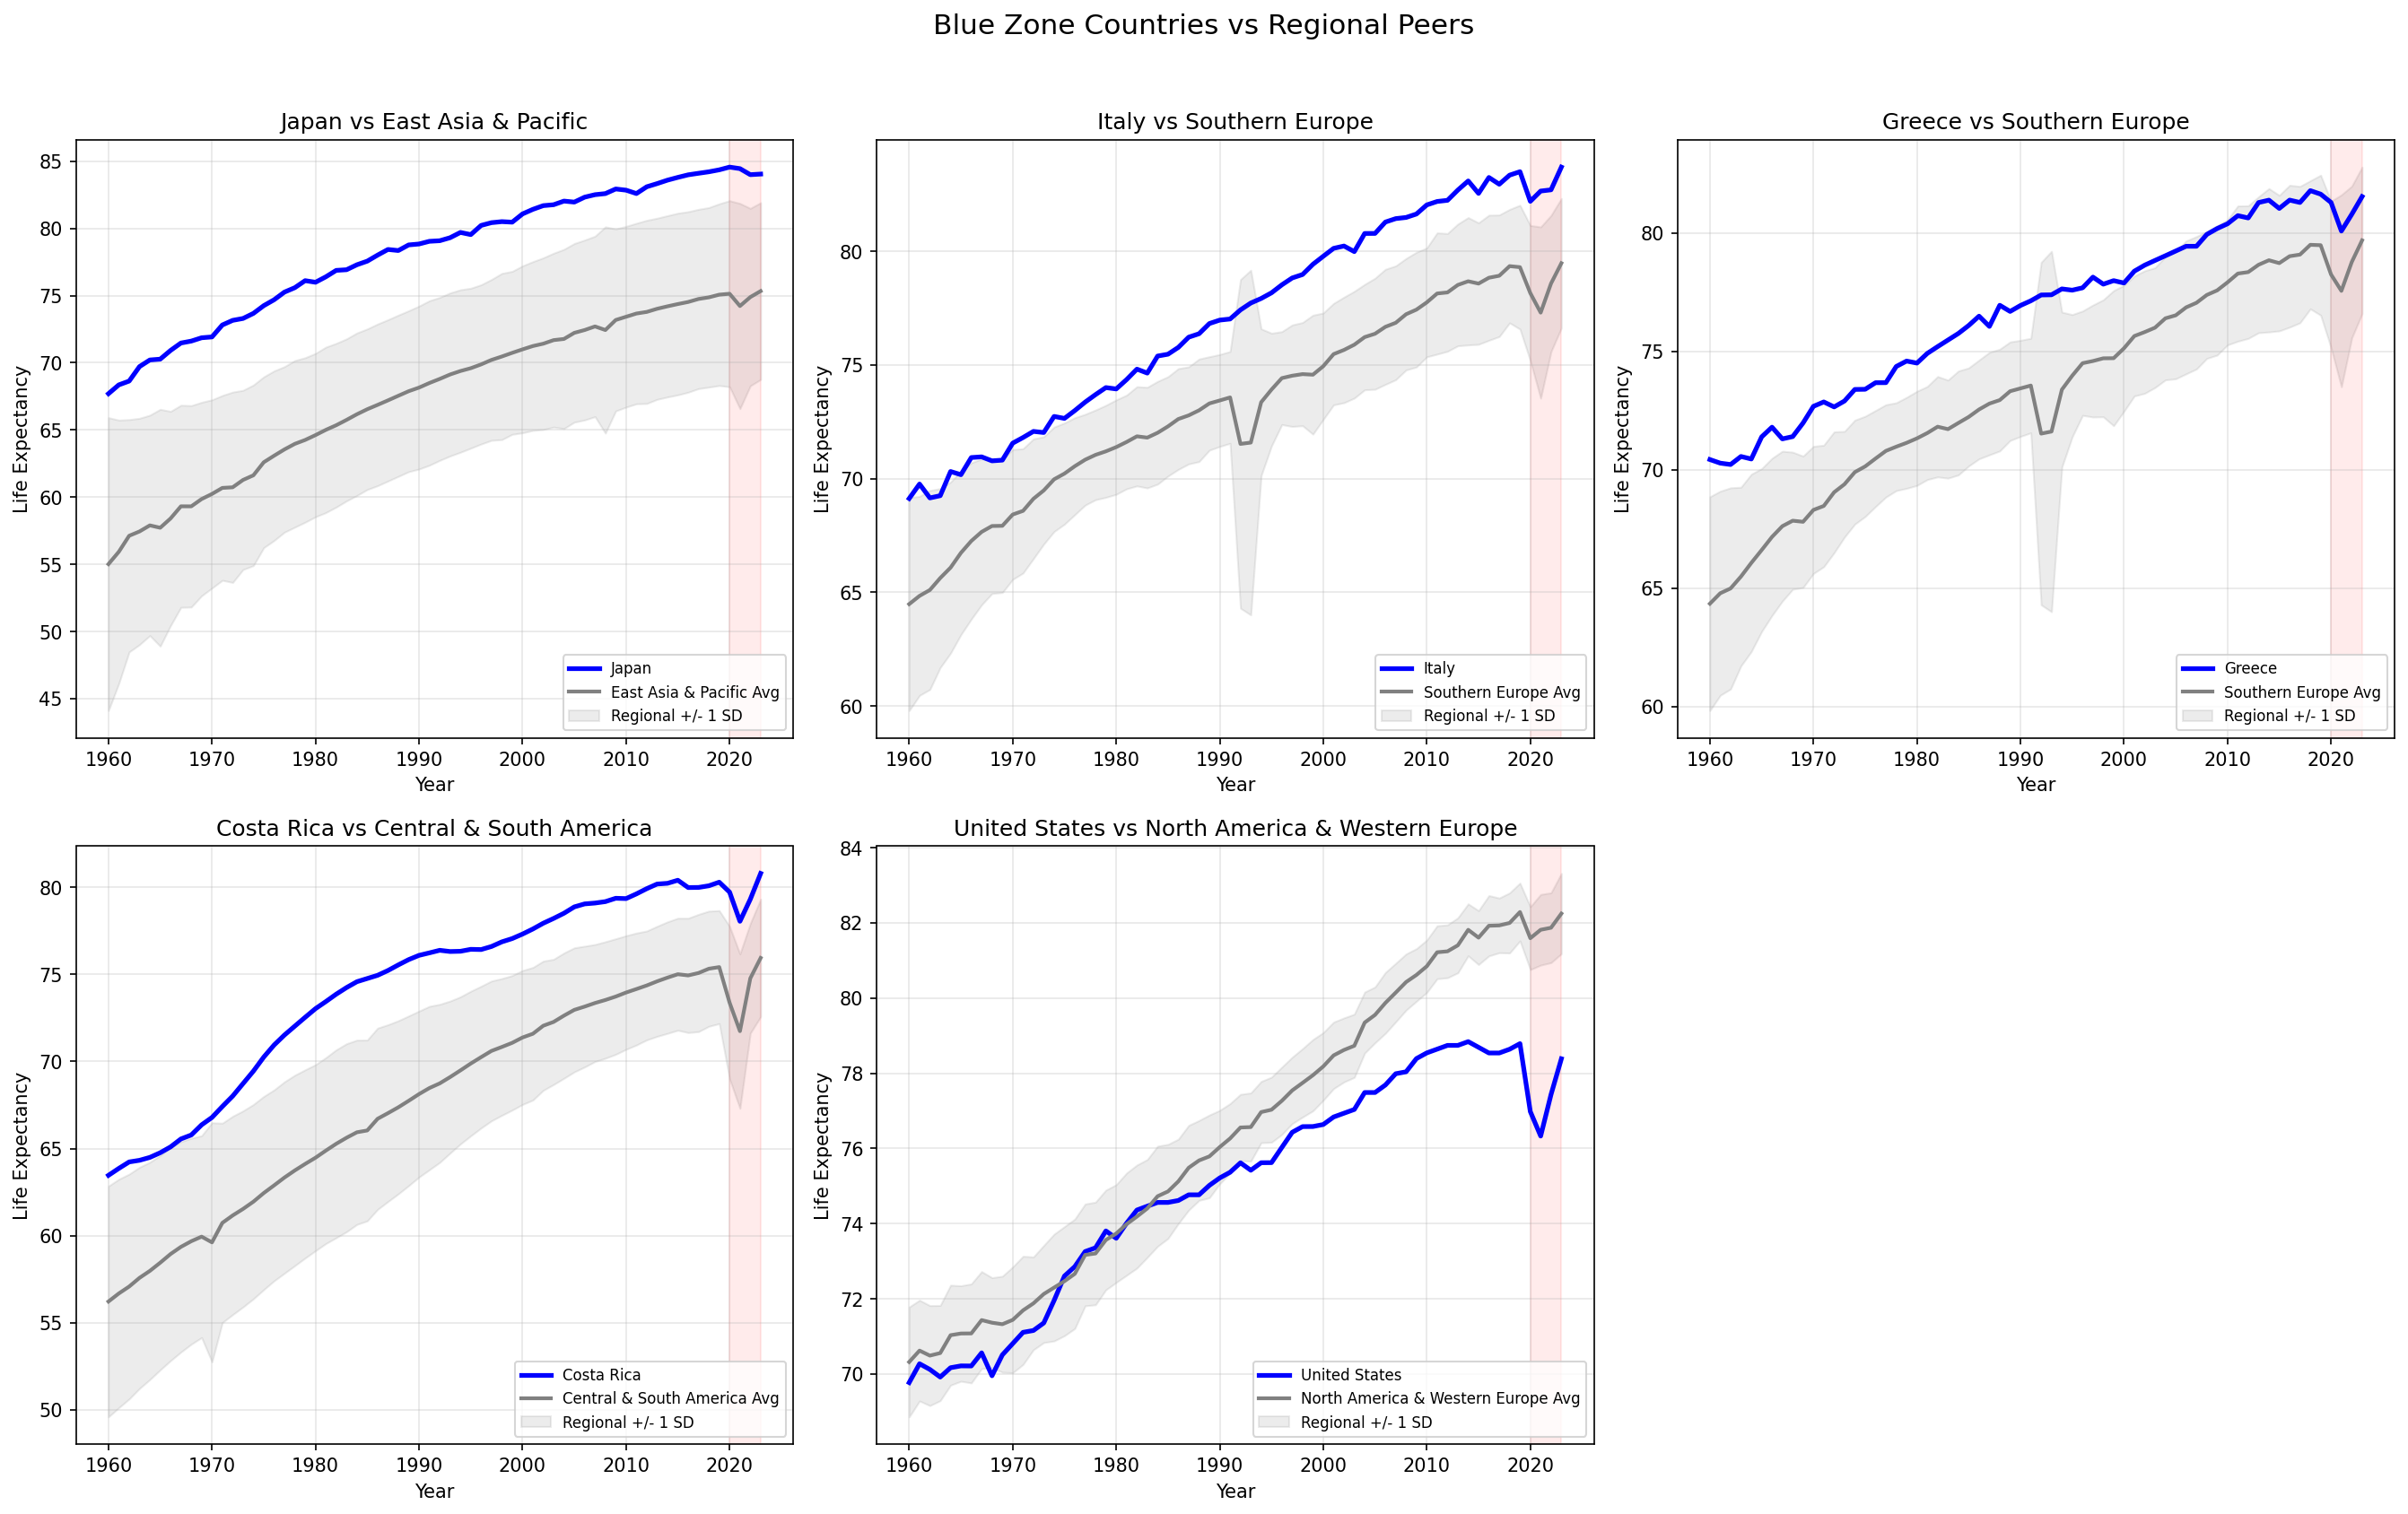

In [10]:
outlier = pd.read_csv(os.path.join(OUTPUT_DIR, 'regional_outlier_tests.csv'))
print("Regional Outlier Tests (2000-2019):\n")
print(outlier[['bz_country', 'region', 'mean_advantage_2000_2019', 'p_value', 'is_regional_outlier']].to_string(index=False))

print("\nKey finding: USA is BELOW its regional peer average (North America & Western Europe)")
print("All other BZ countries are significantly above their regions.")

from IPython.display import Image, display
fig_path = os.path.join(FIGURE_DIR, 'nb07_regional_peers.png')
if os.path.exists(fig_path):
    display(Image(filename=fig_path))


## 10. Income Group Convergence

Convergence analysis within World Bank income groups.
Is the global convergence driven by middle-income countries catching up?

Income Group Convergence Analysis:

       income_group  n_countries  le_improvement  sigma_trend_r  sigma_converging
         Low income            7       20.062671      -0.582839              True
Lower-middle income           21       19.149562       0.355329             False
Upper-middle income           27       14.517427      -0.200593             False
        High income           38       11.524148      -0.784268              True

Findings:
  - Low income countries had the largest LE improvement (+20.1 years)
  - High income countries show the strongest within-group convergence
  - Lower-middle income group is NOT converging internally


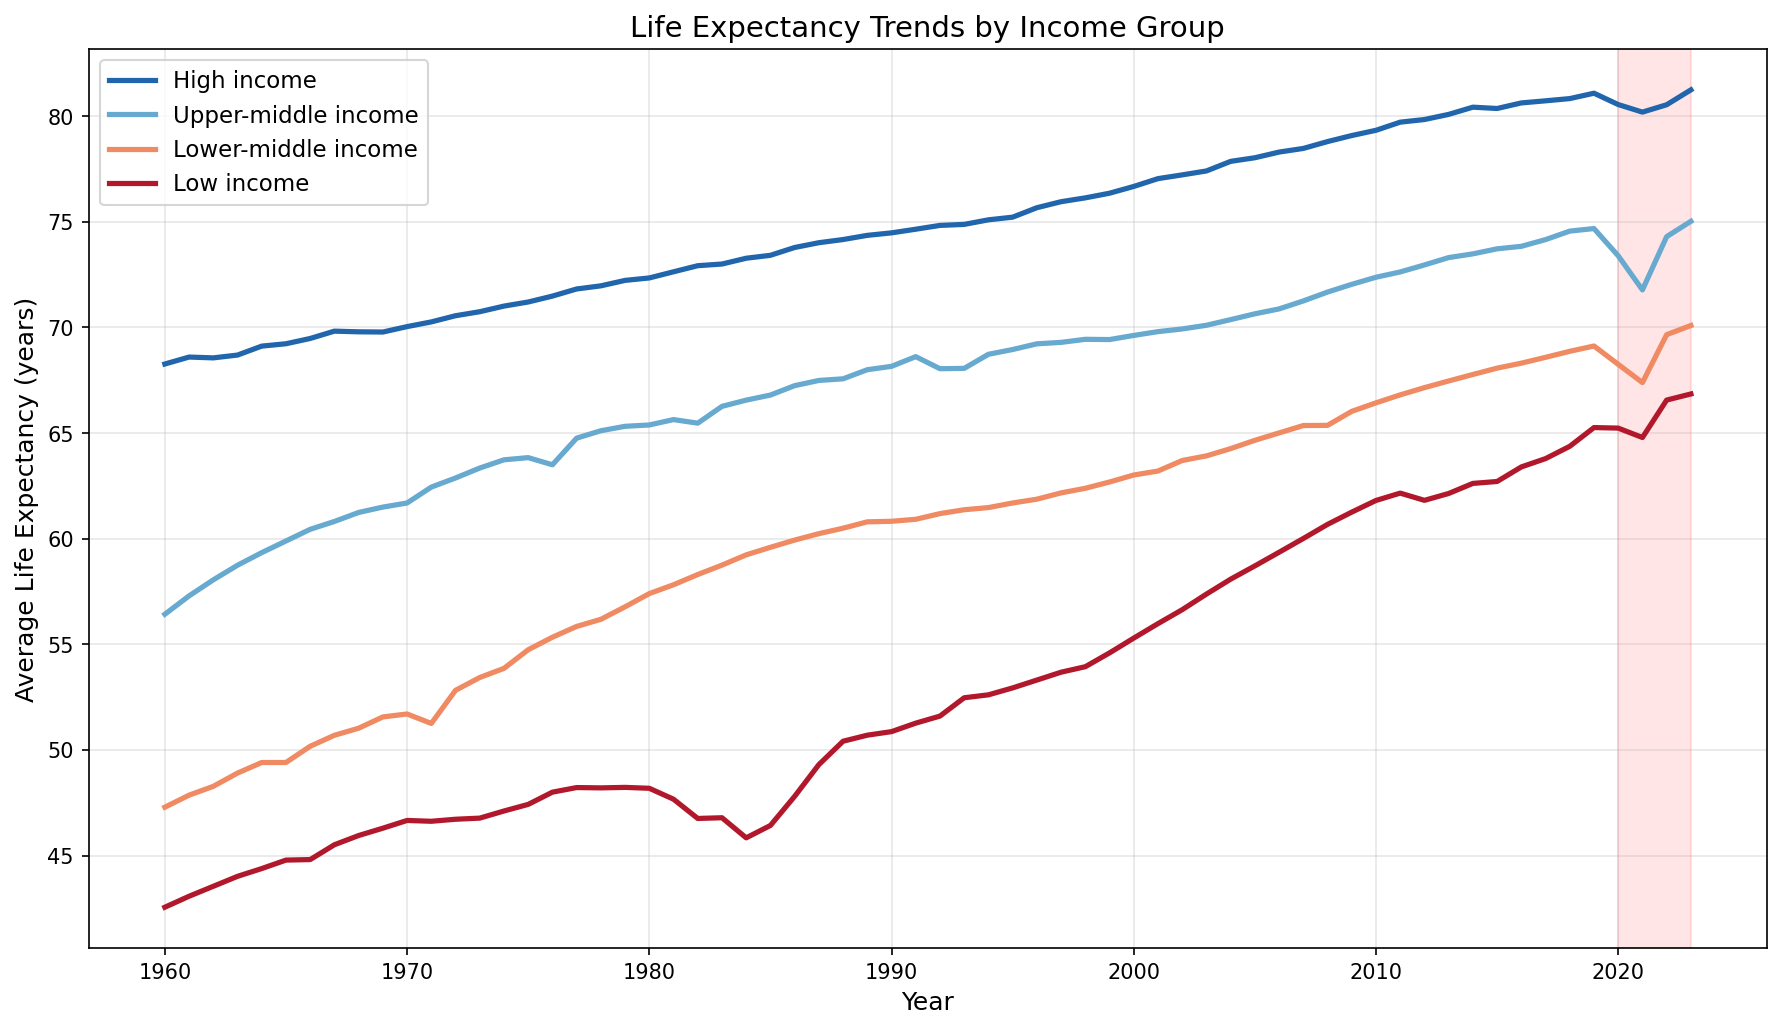

In [11]:
income = pd.read_csv(os.path.join(OUTPUT_DIR, 'income_group_convergence.csv'))
print("Income Group Convergence Analysis:\n")
print(income[['income_group', 'n_countries', 'le_improvement', 'sigma_trend_r', 'sigma_converging']].to_string(index=False))

print("\nFindings:")
print("  - Low income countries had the largest LE improvement (+20.1 years)")
print("  - High income countries show the strongest within-group convergence")
print("  - Lower-middle income group is NOT converging internally")

from IPython.display import Image, display
fig_path = os.path.join(FIGURE_DIR, 'nb07_income_convergence.png')
if os.path.exists(fig_path):
    display(Image(filename=fig_path))


## 11. Time-Series Tests

Augmented Dickey-Fuller tests, structural break at 2020, ARIMA shock analysis.

In [12]:
ts = pd.read_csv(os.path.join(OUTPUT_DIR, 'time_series_tests.csv'))
print("Time-Series Test Results:\n")
for _, row in ts.iterrows():
    print(f"  {row['test']}:")
    print(f"    {row['description']}")
    print(f"    Statistic: {row['statistic']:.3f}, p-value: {row['p_value']:.4f}")
    print(f"    Conclusion: {row['conclusion']}")
    print()


Time-Series Test Results:

  ADF_global_LE:
    Augmented Dickey-Fuller test on global average LE
    Statistic: -2.820, p-value: 0.0555
    Conclusion: Non-stationary (trending)

  ADF_global_LE_diff:
    ADF on first differences of global LE
    Statistic: -4.101, p-value: 0.0010
    Conclusion: Stationary after differencing

  ADF_BZ_gap:
    ADF test on BZ-global gap series
    Statistic: 2.111, p-value: 0.9988
    Conclusion: Non-stationary

  Chow_structural_break_2020:
    Structural break test at 2020 on BZ gap series
    Statistic: 10.824, p-value: 0.0001
    Conclusion: Structural break detected

  ARIMA_COVID_shock:
    ARIMA(1,1,0) residual at 2020 as z-score
    Statistic: 0.013, p-value: 0.9898
    Conclusion: Within normal variation



## 12. COVID Acceleration Test

Does the 2022-2023 gap fall outside the prediction interval
from the pre-COVID trend (1990-2019)?

In [13]:
covid = pd.read_csv(os.path.join(OUTPUT_DIR, 'covid_acceleration_test.csv'))
print("COVID Acceleration Test (OLS trend from 1990-2019):\n")
print(covid[['year', 'predicted_gap', 'actual_gap', 'difference', 'outside_pi']].to_string(index=False))

print("\nInterpretation:")
if any(covid['outside_pi']):
    outside_years = covid[covid['outside_pi']]['year'].tolist()
    print(f"  Years outside prediction interval: {outside_years}")
    print(f"  COVID did accelerate convergence beyond what was expected from the pre-COVID trend.")
else:
    print(f"  All years within prediction interval -- COVID effect is within trend uncertainty.")


COVID Acceleration Test (OLS trend from 1990-2019):

 year  predicted_gap  actual_gap  difference  outside_pi
 2020       6.982614    6.772265   -0.210349       False
 2021       6.883151    6.988408    0.105258       False
 2022       6.783687    5.948525   -0.835162        True
 2023       6.684224    6.188893   -0.495331       False

Interpretation:
  Years outside prediction interval: [2022]
  COVID did accelerate convergence beyond what was expected from the pre-COVID trend.


## 13. Decade Improvement Differences

Independent t-tests comparing BZ gains vs non-BZ gains per decade.
Cohen's d measures effect size.

In [14]:
decade = pd.read_csv(os.path.join(OUTPUT_DIR, 'decade_improvement_tests.csv'))
print("Decade Improvement t-tests (BZ vs Non-BZ gains):\n")
print(decade[['decade', 'bz_mean_gain', 'non_bz_mean_gain', 'cohens_d', 'effect_size', 'p_value']].to_string(index=False))

print("\nKey finding: In 2000-2010 and 2010-2019, non-BZ countries gained")
print("significantly more than BZ countries (convergence is accelerating).")
print("BZ countries gained less because they started higher -- ceiling effect.")


Decade Improvement t-tests (BZ vs Non-BZ gains):

   decade  bz_mean_gain  non_bz_mean_gain  cohens_d effect_size  p_value
1960-1970      2.653215          3.616535 -0.261775       small 0.182326
1970-1980      3.465776          3.411586  0.017276       small 0.951797
1980-1990      2.594590          2.655449 -0.024900       small 0.874982
1990-2000      1.728015          2.174132 -0.146973       small 0.366127
2000-2010      2.093400          3.207130 -0.621123      medium 0.000036
2010-2019      1.082839          2.319713 -0.679255      medium 0.001688

Key finding: In 2000-2010 and 2010-2019, non-BZ countries gained
significantly more than BZ countries (convergence is accelerating).
BZ countries gained less because they started higher -- ceiling effect.


## 14. Summary of Statistical Findings

All key results compiled from the comprehensive statistical analysis.

In [15]:
summary = pd.read_csv(os.path.join(OUTPUT_DIR, 'statistical_tests_summary.csv'))
print("Statistical Tests Summary:\n")
print(summary[['test_name', 'statistic_value', 'p_value', 'conclusion']].to_string(index=False))

print("\n" + "=" * 70)
print("KEY CONCLUSIONS")
print("=" * 70)
print()
print("1. SIGNIFICANCE: The BZ gap is statistically significant (p<0.05)")
print("   for ALL 64 years analyzed (1960-2023).")
print()
print("2. CONVERGENCE: Beta convergence is significant in 4 of 6 decades")
print("   after Bonferroni correction. Sigma convergence has a slope of")
print("   -0.053 SD/year (R2=0.85, p<0.001).")
print()
print("3. GDP CONTROLS: Health expenditure and Gini index correlations")
print("   with LE are largely explained by GDP. Physician density,")
print("   water access, and fertility remain significant after controlling.")
print()
print("4. SENSITIVITY: Removing the USA increases the BZ gap by +0.73 years.")
print("   Removing Japan decreases it by -0.66 years. The BZ advantage is")
print("   robust to any single country removal.")
print()
print("5. REGIONAL: All BZ countries except the USA are significant outliers")
print("   above their regional peer averages. The USA falls BELOW the")
print("   North America & Western Europe average.")
print()
print("6. GENDER: The BZ advantage is nearly equal for males and females")
print("   (within 0.1 years). Gender gap trends are similar in BZ and globally.")
print()
print("7. COVID: Structural break confirmed at 2020 (Chow F=10.8, p<0.001).")
print("   The 2022 gap fell outside the pre-COVID trend prediction interval.")


Statistical Tests Summary:

                      test_name  statistic_value      p_value                                 conclusion
      BZ Gap (most recent year)         6.188893 6.000000e-03    Gap of 6.2 years, significant at p<0.05
     Beta Convergence 1960-1970        -0.574805 1.243959e-08     r=-0.575, significant after Bonferroni
     Beta Convergence 1970-1980        -0.449965 3.621895e-05     r=-0.450, significant after Bonferroni
     Beta Convergence 1980-1990        -0.213024 2.421073e-01 r=-0.213, not significant after Bonferroni
     Beta Convergence 1990-2000        -0.087705 1.000000e+00 r=-0.088, not significant after Bonferroni
     Beta Convergence 2000-2010        -0.651764 8.934116e-12     r=-0.652, significant after Bonferroni
     Beta Convergence 2010-2019        -0.640625 2.796748e-11     r=-0.641, significant after Bonferroni
  Sigma Convergence (pre_covid)        -0.053100 3.350671e-25                Slope=-0.0531/yr, declining
Sigma Convergence (full_per